In [128]:
from torchvision import datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [129]:
transform = T.ToTensor()
train_ds = datasets.MNIST(root="./data", download=True, transform=transform, train=True)
test_ds = datasets.MNIST(root="./data", download=True, transform=transform, train=False)

In [130]:
t_ds = datasets.MNIST(root="./data", download=True, transform=transform, train=False)

In [131]:
X = train_ds.data[:5000].numpy()
y = train_ds.targets[:5000].numpy()

X: np.ndarray = X.reshape(5000, -1)
X = X / 255.0
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

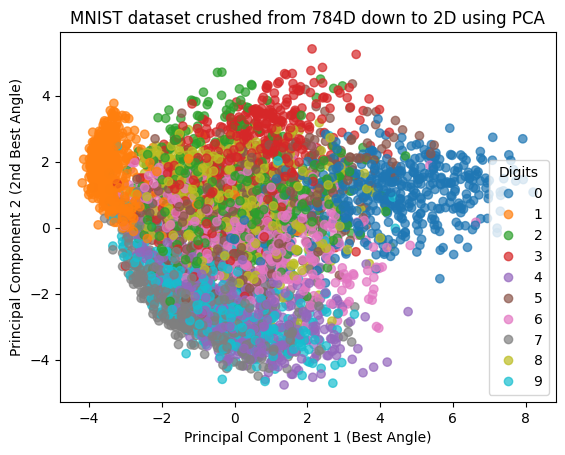

In [132]:
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', alpha=0.7)
plt.title("MNIST dataset crushed from 784D down to 2D using PCA")
plt.xlabel("Principal Component 1 (Best Angle)")
plt.ylabel("Principal Component 2 (2nd Best Angle)")
# This handy little trick pulls the legend out automatically from your scatter plot
plt.legend(*scatter.legend_elements(), title="Digits")
plt.show()

In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Take the labels (y) and our 2D summary (X_pca) 
# and split them into a training and testing set
split_index = 4000
X_train, X_test = X_pca[:split_index], X_pca[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 2. Build the exact classifier you just mentioned
clf = DecisionTreeClassifier(max_depth=10, random_state=42)

# 3. Fit it using ONLY the 2 lines of PCA data!
clf.fit(X_train, y_train)

# 4. Predict and see how well it works
predictions = clf.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"{accuracy * 100:.2f}%")


45.60%


In [134]:
kmeans = KMeans(n_clusters=10)
cluster_labels = kmeans.fit_predict(X_pca)

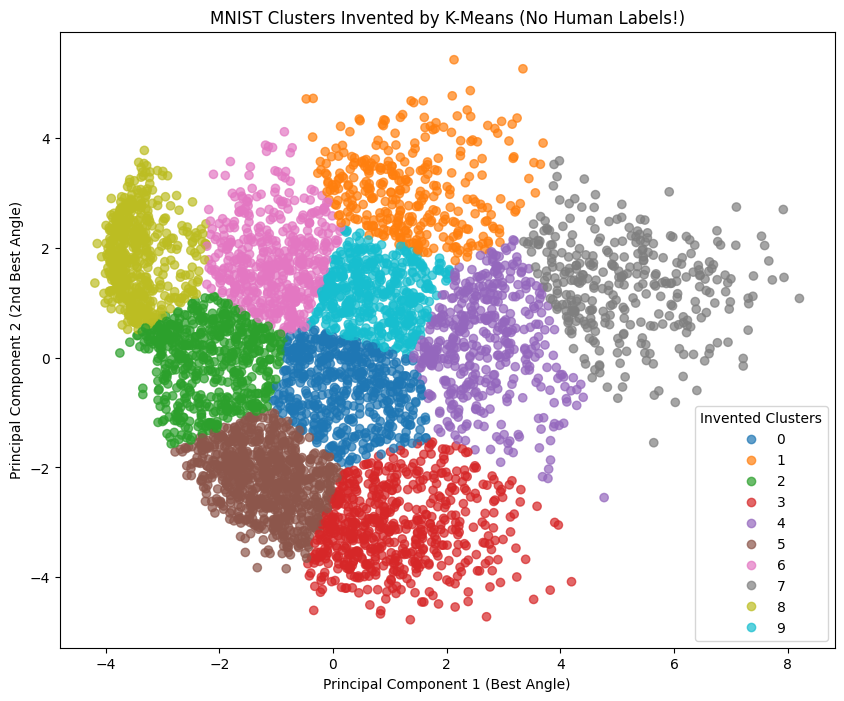

In [135]:
plt.figure(figsize=(10, 8))

# Notice the change here: c=cluster_labels
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)

plt.title("MNIST Clusters Invented by K-Means (No Human Labels!)")
plt.xlabel("Principal Component 1 (Best Angle)")
plt.ylabel("Principal Component 2 (2nd Best Angle)")

# This adds a legend matching the colors to the clusters
plt.legend(*scatter.legend_elements(), title="Invented Clusters")

plt.show()


In [136]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


In [137]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        return x

In [138]:
device = "cuda" if torch.cuda.is_available() else "cpu"
trainLoader = DataLoader(train_ds, batch_size=32)
testLoader = DataLoader(test_ds, batch_size=32)
model = Net().to(device)
optimizer = optim.Adam(model.parameters(), 1e-3)
epochs = 10
criterion = nn.CrossEntropyLoss()

In [139]:
import copy

def train(model, epochs, optimizer, train_loader, test_loader, criterion, device):
    best_accuracy = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.reshape(batch_X.size(0), -1)
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0   
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.reshape(batch_X.size(0), -1)
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
        val_loss = val_loss / len(train_loader) # Replace with len(val_loader)
        val_accuracy = correct / total
        
        # --- Save Best Model ---
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
    
        print(f"Epoch: {epoch+1}/{epochs}\tTrain Loss: {train_loss:.4f}\tVal Loss: {val_loss:.4f}\tVal Acc: {val_accuracy:.4f}")
    model.load_state_dict(best_model_wts)
    print(f"Training complete. Best Validation Accuracy: {best_accuracy:.4f}")

In [141]:
train(model, epochs, optimizer, trainLoader, testLoader, criterion, device)

Epoch: 1/10	Train Loss: 0.0149	Val Loss: 0.0199	Val Acc: 0.9763
Epoch: 2/10	Train Loss: 0.0141	Val Loss: 0.0260	Val Acc: 0.9693
Epoch: 3/10	Train Loss: 0.0151	Val Loss: 0.0212	Val Acc: 0.9768
Epoch: 4/10	Train Loss: 0.0123	Val Loss: 0.0200	Val Acc: 0.9771
Epoch: 5/10	Train Loss: 0.0110	Val Loss: 0.0303	Val Acc: 0.9697
Epoch: 6/10	Train Loss: 0.0141	Val Loss: 0.0209	Val Acc: 0.9790
Epoch: 7/10	Train Loss: 0.0116	Val Loss: 0.0181	Val Acc: 0.9793
Epoch: 8/10	Train Loss: 0.0093	Val Loss: 0.0229	Val Acc: 0.9773
Epoch: 9/10	Train Loss: 0.0106	Val Loss: 0.0218	Val Acc: 0.9796
Epoch: 10/10	Train Loss: 0.0098	Val Loss: 0.0255	Val Acc: 0.9768
Training complete. Best Validation Accuracy: 0.9796
